Plot successfully saved to Supplementary_Figure_S1b.pdf.


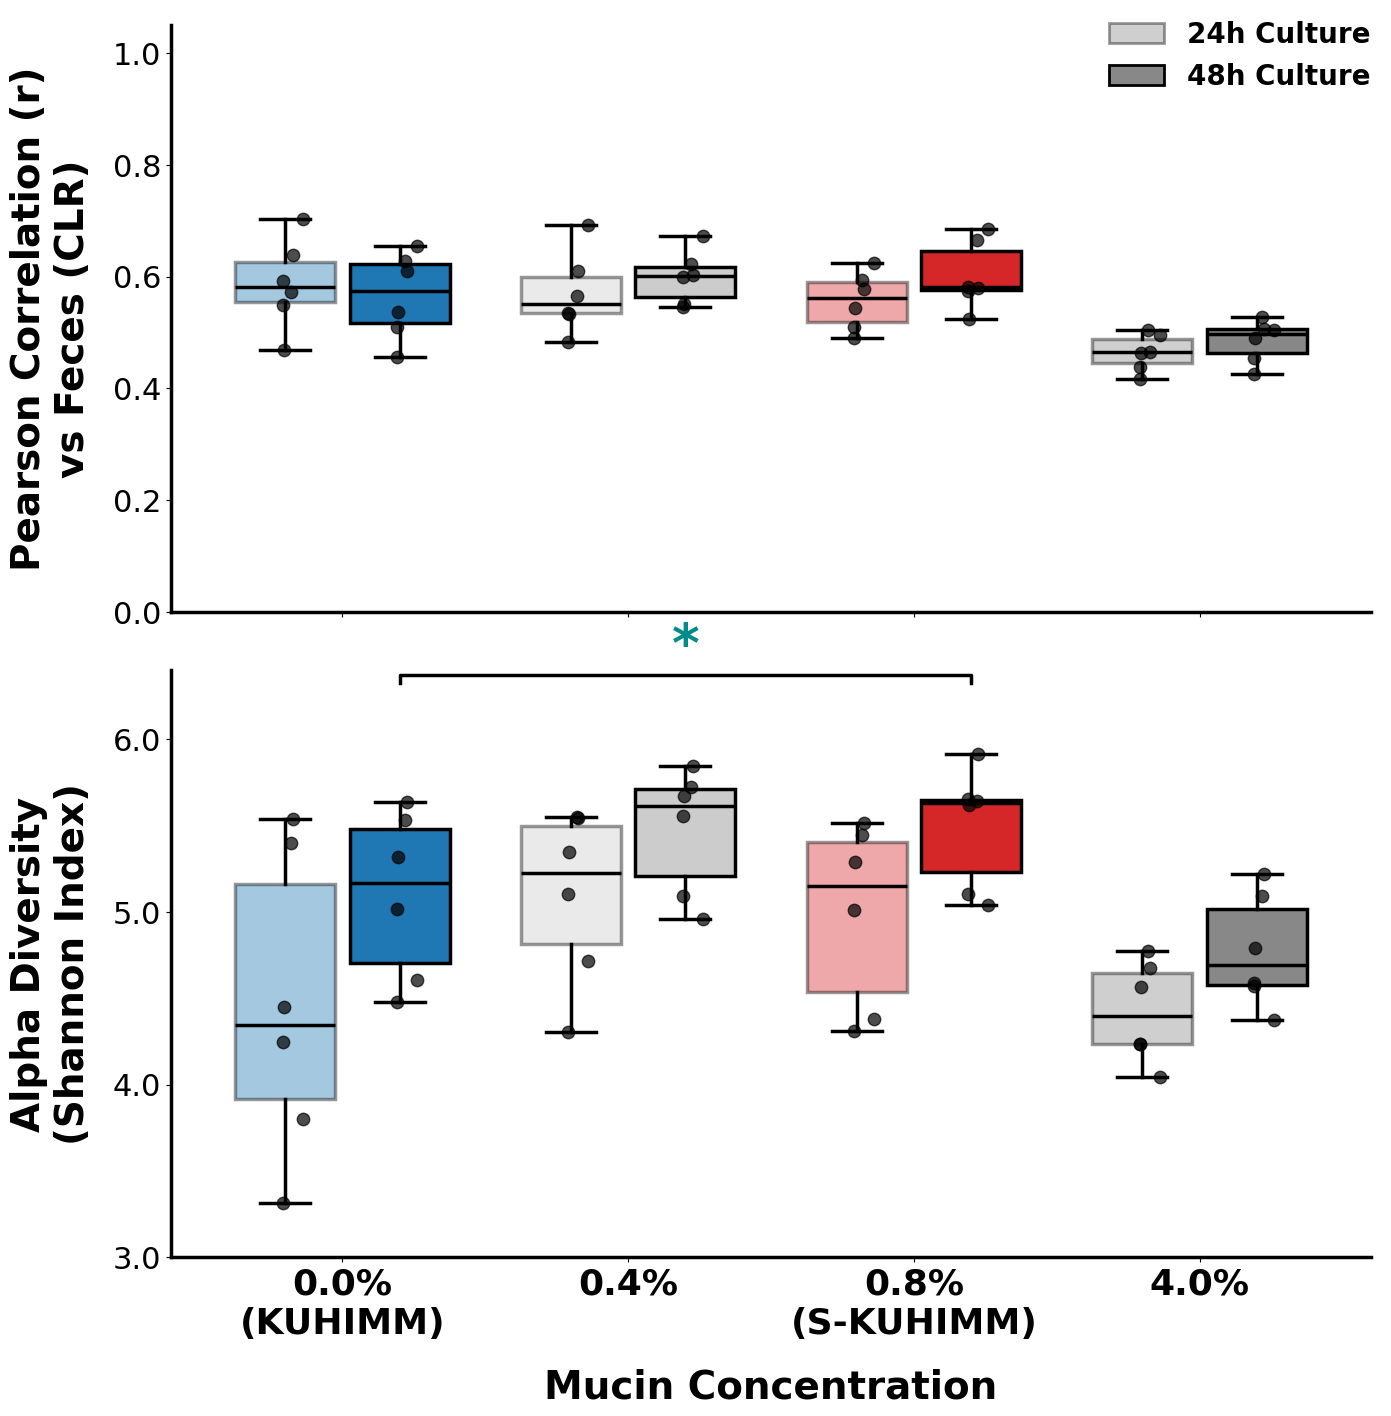

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, wilcoxon
from scipy.stats.mstats import gmean
from matplotlib.patches import Patch
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Nature Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 24,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular'
})

# Universal Settings for Significance Markers
STAR_COLOR = '#008B8B'  # Dark Turquoise
STAR_SIZE = 38

# =============================================================================
# 1. Load Data & Pre-processing
# =============================================================================
def clr_transform(x):
    """Perform Centered Log-Ratio (CLR) transformation with robust pseudocounts."""
    x = np.array(x, dtype=float)
    if (x == 0).any():
        pseudo = x[x > 0].min() * 0.5 if (x > 0).any() else 1e-9
        x = np.where(x == 0, pseudo, x)
    return np.log(x / gmean(x))

def extract_time(subject_id):
    """Standardize timepoint extraction."""
    if 'FEC' in subject_id: return '0h'
    elif '24h' in subject_id: return '24h'
    elif '48h' in subject_id: return '48h'
    return 'Exclude'

# --- 1.1 Microbiome Stability (Pearson r) ---
df_16s = pd.read_csv("(S1)_mucin_16S_Genus_level.csv")
taxa_cols = [c for c in df_16s.columns if c.startswith('d__') or c.startswith('Unassigned')]
df_16s['Time'] = df_16s['Subject'].apply(extract_time)

results_pearson = []
clusters = df_16s['Cluster'].unique()
features = ['0.0% Mucin (KUHIMM)', '0.4% Mucin', '0.8% Mucin (S-KUHIMM)', '4.0% Mucin']

for cl in clusters:
    df_cl = df_16s[df_16s['Cluster'] == cl]
    inoculum = df_cl[df_cl['Time'] == '0h']
    if not inoculum.empty:
        inoc_vals = inoculum[taxa_cols].values[0].astype(float)
        for t in ['24h', '48h']:
            for feat in features:
                target = df_cl[(df_cl['Time'] == t) & (df_cl['Feature'] == feat)]
                if not target.empty:
                    target_vals = target[taxa_cols].values[0].astype(float)
                    mask = (inoc_vals > 0) | (target_vals > 0)
                    if mask.sum() > 3:
                        r, _ = pearsonr(clr_transform(inoc_vals[mask]), clr_transform(target_vals[mask]))
                        results_pearson.append({'Donor': cl, 'Time': t, 'Condition': feat, 'Pearson_CLR': r})

df_pearson = pd.DataFrame(results_pearson)

# --- 1.2 Alpha Diversity (Shannon Index) ---
df_shannon_raw = pd.read_csv("(S1)_mucin_shannon.csv")
depth_cols = [c for c in df_shannon_raw.columns if 'depth' in c]
df_shannon_raw['Max_Shannon'] = df_shannon_raw[depth_cols].max(axis=1)
df_shannon_raw['Time'] = df_shannon_raw['Subject'].apply(extract_time)

results_shannon = []
for cl in clusters:
    df_cl = df_shannon_raw[df_shannon_raw['Cluster'] == cl]
    for t in ['24h', '48h']:
        for feat in features:
            row = df_cl[(df_cl['Time'] == t) & (df_cl['Feature'] == feat)]
            if not row.empty:
                results_shannon.append({'Donor': cl, 'Time': t, 'Condition': feat, 'Shannon': row['Max_Shannon'].values[0]})

df_shannon = pd.DataFrame(results_shannon)

# =============================================================================
# 2. Integrated Visualization (Supplementary Figure S1)
# =============================================================================
palette = {
    '0.0% Mucin (KUHIMM)': '#1f77b4',   # Conventional Blue
    '0.4% Mucin': '#cccccc',            # Neutral Gray
    '0.8% Mucin (S-KUHIMM)': '#d62728', # Optimized Red
    '4.0% Mucin': '#888888'             # Excessive Dark Gray
}

# Share X-axis to align the two panels cleanly
fig, axes = plt.subplots(2, 1, figsize=(16, 16), sharex=True, gridspec_kw={'hspace': 0.1})

def annotate_bracket(ax, x1, x2, y_base, h, text):
    """Draws a strict, professional statistical bracket with a turquoise asterisk."""
    ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=2.5, c='k')
    ax.text((x1+x2)*0.5, y_base+h + h*0.2, text, ha='center', va='bottom',
            color=STAR_COLOR, fontsize=STAR_SIZE, fontweight='bold')

def draw_panel(ax, df_data, val_col, y_label, y_lims, y_ticks, draw_xticklabels=False):
    """Custom function to draw dodged boxplots with time-based transparency and stats."""
    for i, cond in enumerate(features):

        # --- 24h Data (Dodged Left, Alpha=0.4) ---
        d24 = df_data[(df_data['Condition'] == cond) & (df_data['Time'] == '24h')].dropna()
        if not d24.empty:
            box_24 = ax.boxplot(d24[val_col], positions=[i - 0.2], widths=0.35, patch_artist=True, showfliers=False)
            for patch in box_24['boxes']:
                patch.set_facecolor(palette[cond])
                patch.set_alpha(0.4) # Semi-transparent for 24h
                patch.set_edgecolor('black')
                patch.set_linewidth(2.5)
            # Enforce black, thick lines for whiskers and medians
            for whisker in box_24['whiskers']: whisker.set(color='black', linewidth=2.5)
            for cap in box_24['caps']: cap.set(color='black', linewidth=2.5)
            for median in box_24['medians']: median.set(color='black', linewidth=2.5)

            np.random.seed(42) # Keep points horizontally stable
            ax.scatter(np.random.normal(i - 0.2, 0.04, size=len(d24)), d24[val_col],
                       color='black', alpha=0.7, s=80, zorder=3)

        # --- 48h Data (Dodged Right, Alpha=1.0) ---
        d48 = df_data[(df_data['Condition'] == cond) & (df_data['Time'] == '48h')].dropna()
        if not d48.empty:
            box_48 = ax.boxplot(d48[val_col], positions=[i + 0.2], widths=0.35, patch_artist=True, showfliers=False)
            for patch in box_48['boxes']:
                patch.set_facecolor(palette[cond])
                patch.set_alpha(1.0) # Solid for 48h
                patch.set_edgecolor('black')
                patch.set_linewidth(2.5)
            for whisker in box_48['whiskers']: whisker.set(color='black', linewidth=2.5)
            for cap in box_48['caps']: cap.set(color='black', linewidth=2.5)
            for median in box_48['medians']: median.set(color='black', linewidth=2.5)

            np.random.seed(42)
            ax.scatter(np.random.normal(i + 0.2, 0.04, size=len(d48)), d48[val_col],
                       color='black', alpha=0.7, s=80, zorder=3)

    # Y-axis styling
    ax.set_ylabel(y_label, fontsize=28, fontweight='bold', labelpad=15)
    ax.set_ylim(y_lims)
    ax.set_yticks(y_ticks)

    # FORCE NORMAL WEIGHT for Y-axis ticks
    labels_y = ax.set_yticklabels([f"{t:.1f}" for t in y_ticks], fontsize=22)
    for label in labels_y:
        label.set_fontweight('normal')

    # X-axis limits & aesthetics
    ax.set_xlim(-0.6, len(features) - 0.4)
    ax.set_xticks(range(len(features)))

    if draw_xticklabels:
        ax.set_xticklabels(['0.0%\n(KUHIMM)', '0.4%', '0.8%\n(S-KUHIMM)', '4.0%'], fontsize=26, fontweight='bold')
    else:
        ax.set_xticklabels([])

    # =========================================================================
    # Statistical Testing (0.0% vs 0.8% at 24h and 48h)
    # =========================================================================
    data_max = df_data[val_col].max()
    y_range = y_lims[1] - y_lims[0]
    bracket_h = y_range * 0.015

    for time_pt, offset, y_base_ratio in zip(['24h', '48h'], [-0.2, 0.2], [0.05, 0.12]):
        kuhimm = df_data[(df_data['Condition'] == '0.0% Mucin (KUHIMM)') & (df_data['Time'] == time_pt)].sort_values('Donor')[val_col].values
        skuhimm = df_data[(df_data['Condition'] == '0.8% Mucin (S-KUHIMM)') & (df_data['Time'] == time_pt)].sort_values('Donor')[val_col].values

        if len(kuhimm) == len(skuhimm) and len(kuhimm) > 0:
            _, p = wilcoxon(kuhimm, skuhimm)
            if p < 0.05:
                y_base = data_max + y_range * y_base_ratio
                annotate_bracket(ax, 0 + offset, 2 + offset, y_base, bracket_h, '*')

# =============================================================================
# FIX: Draw Top Panel (Pearson) with 0.0 to 1.0 (with slight overhead for brackets)
# =============================================================================
draw_panel(axes[0], df_pearson, 'Pearson_CLR', "Pearson Correlation (r)\nvs Feces (CLR)",
           (0.0, 1.05), [0.0, 0.2, 0.4, 0.6, 0.8, 1.0], draw_xticklabels=False)

# Draw Bottom Panel (Shannon)
draw_panel(axes[1], df_shannon, 'Shannon', "Alpha Diversity\n(Shannon Index)",
           (3.0, 6.4), [3.0, 4.0, 5.0, 6.0], draw_xticklabels=True)
axes[1].set_xlabel("Mucin Concentration", fontsize=28, fontweight='bold', labelpad=20)

# Add Legend to Top Panel indicating Time
legend_elements = [
    Patch(facecolor='#888888', alpha=0.4, edgecolor='black', linewidth=2, label='24h Culture'),
    Patch(facecolor='#888888', alpha=1.0, edgecolor='black', linewidth=2, label='48h Culture')
]
axes[0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.02, 1.05),
               fontsize=20, frameon=False)

sns.despine()
plt.tight_layout()

# Export High-Resolution PDF
output_file = "Supplementary_Figure_S1b.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.2)
print(f"Plot successfully saved to {output_file}.")